In [1]:
# Importowanie bibliotek niezbędnych do analizy i wizualizacji danych
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Wyciszenie ostrzeżenia o małej liczbie próbek w klasach (CV)
warnings.filterwarnings(
    "ignore",
    message="The least populated class in y has only"
)

In [2]:
# Wczytanie zbiorów danych czerwonego i białego wina z plików CSV
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

In [ ]:
# Dodanie kolumny identyfikującej typ wina i połączenie zbiorów w jeden DataFrame
df_red['type'] = 'red'
df_white['type'] = 'white'

df = pd.concat([df_red, df_white], ignore_index=True)

In [4]:
# Podgląd podstawowych informacji o datasecie
print(f'Rozmiar datasetu: {df.shape}')
print(f'\nPierwsze 5 wierszy:')
display(df.head())
print(f'\nOstatnie 5 wierszy:')
display(df.tail())
print(f'\nBrakujące wartości:')
print(df.isnull().sum())

Rozmiar datasetu: (6497, 13)

Pierwsze 5 wierszy:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red



Ostatnie 5 wierszy:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white



Brakujące wartości:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [5]:
# Statystyki opisowe dla wszystkich cech numerycznych
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


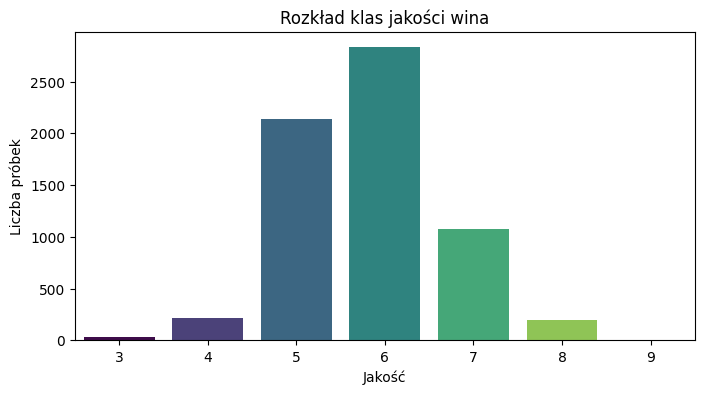


Liczba próbek per klasa:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [6]:
# Rozkład klas jakości wina - analiza balansu datasetu
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, hue='quality', palette='viridis', legend=False)
plt.title('Rozkład klas jakości wina')
plt.xlabel('Jakość')
plt.ylabel('Liczba próbek')
plt.show()

print('\nLiczba próbek per klasa:')
print(df['quality'].value_counts().sort_index())

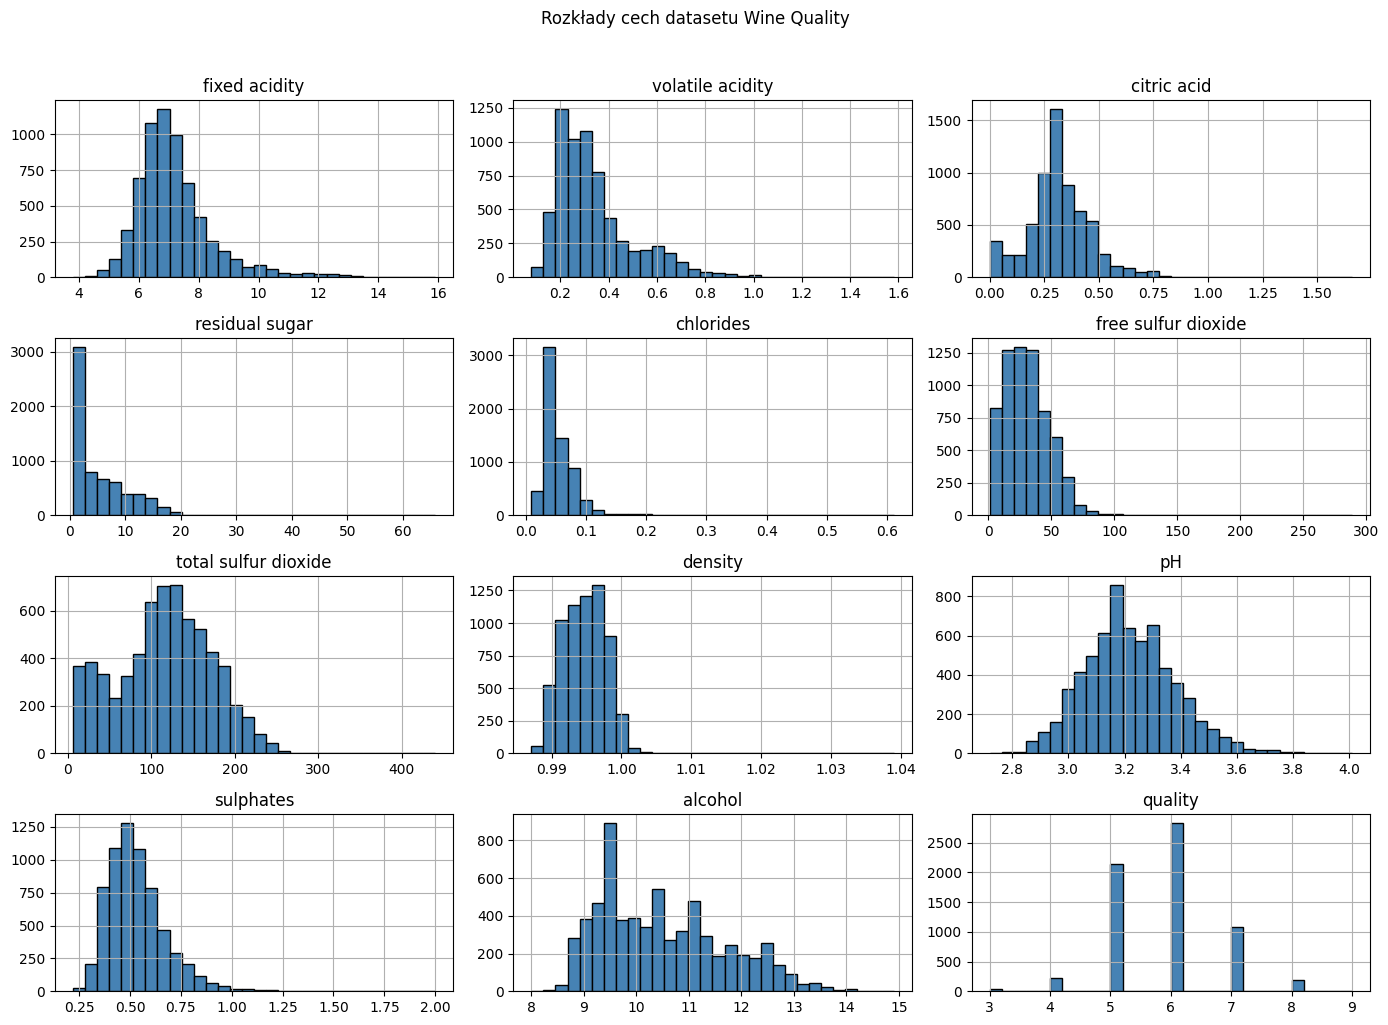

In [7]:
# Histogramy rozkładów wszystkich cech numerycznych datasetu
df.drop(columns=['type']).hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Rozkłady cech datasetu Wine Quality', y=1.02)
plt.tight_layout()
plt.show()

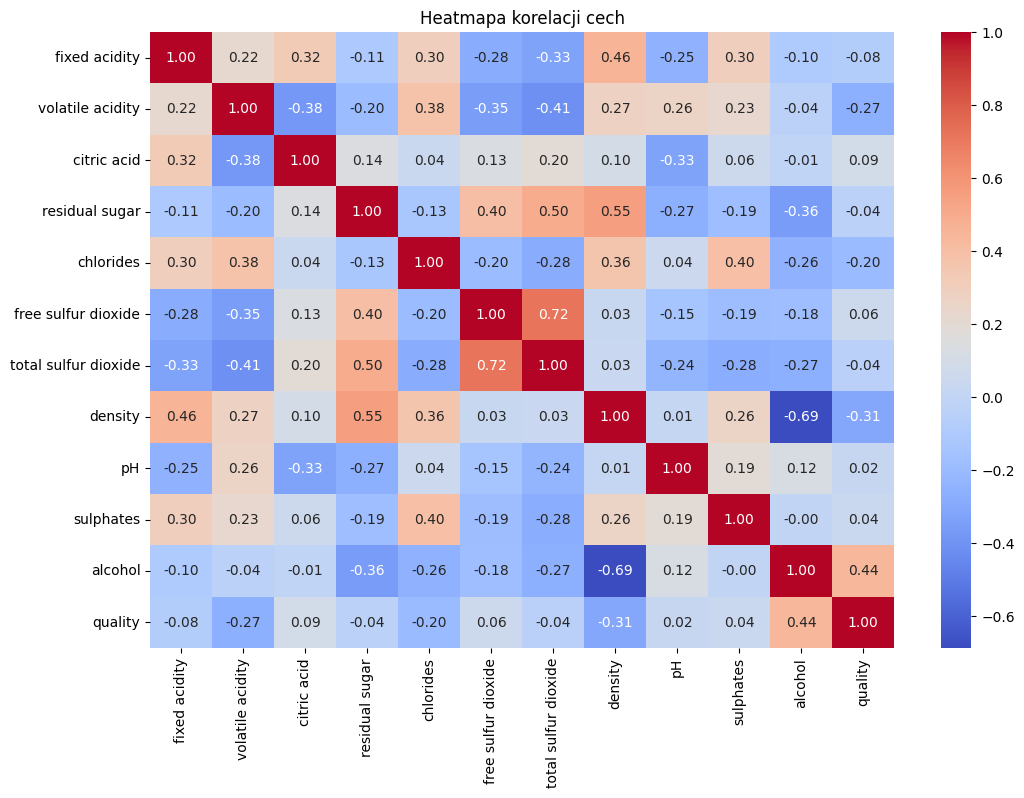

In [8]:
# Macierz korelacji między wszystkimi cechami datasetu
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['type']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmapa korelacji cech')
plt.show()

In [9]:
# Podział datasetu na cechy wejściowe (X) i zmienną docelową (y)
X = df.drop(['quality'], axis=1)
y = df['quality']
X = pd.get_dummies(X, columns=['type'], drop_first=True)

print(f'Wymiary X: {X.shape}')
print(f'Wymiary y: {y.shape}')
print('\nRozkład klas:')
print(y.value_counts().sort_index())

Wymiary X: (6497, 12)
Wymiary y: (6497,)

Rozkład klas:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [10]:
# Podział danych na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
print(f'Zbiór testowy: {X_test.shape[0]} próbek')

Zbiór treningowy: 5197 próbek
Zbiór testowy: 1300 próbek


In [ ]:
# Standaryzacja cech - skalowanie do średniej 0 i odchylenia standardowego 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Średnia po skalowaniu (train): {X_train_scaled.mean():.4f}')
print(f'Std po skalowaniu (train): {X_train_scaled.std():.4f}')

Średnia po skalowaniu (train): -0.0000
Std po skalowaniu (train): 1.0000


In [12]:
# Definicja i trening bazowego modelu MLP
clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True
)
clf.fit(X_train_scaled, y_train)

print(f'Accuracy (model bazowy): {clf.score(X_test_scaled, y_test):.4f}')

Accuracy (model bazowy): 0.5546


In [13]:
# Raport klasyfikacji dla modelu bazowego
y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.50      0.02      0.04        43
           5       0.62      0.62      0.62       428
           6       0.54      0.66      0.60       567
           7       0.45      0.36      0.40       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1300
   macro avg       0.30      0.24      0.24      1300
weighted avg       0.53      0.55      0.53      1300



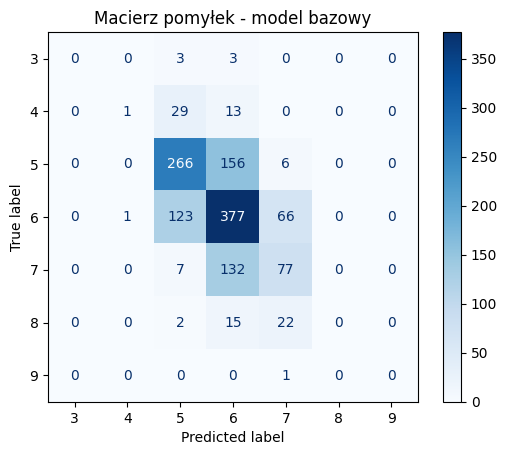

In [14]:
# Macierz pomyłek dla modelu bazowego
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot(cmap='Blues')
plt.title('Macierz pomyłek - model bazowy')
plt.show()

In [15]:
# Grid Search z walidacją krzyżową dla modelu MLP
params = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter':           [500],
}

grid = GridSearchCV(
    MLPClassifier(
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1,
    ),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

start = time.time()
grid.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f'Czas przeszukiwania: {elapsed:.1f} s')
print('\nNajlepsze parametry:')
print(grid.best_params_)
print(f'\nNajlepszy wynik CV (accuracy): {grid.best_score_:.4f}')

best_model = grid.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Czas przeszukiwania: 45.2 s

Najlepsze parametry:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 500}

Najlepszy wynik CV (accuracy): 0.5703


In [16]:
# Trening finalnego modelu wybranego przez Grid Search
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

print('Finalny model wytrenowany na podstawie Grid Search!')

Finalny model wytrenowany na podstawie Grid Search!


In [17]:
# Ewaluacja finalnego modelu
y_pred_best = best_model.predict(X_test_scaled)

print('Wyniki finalnego modelu')
print()
print(f'Accuracy: {best_model.score(X_test_scaled, y_test):.4f}')
print()
print(classification_report(y_test, y_pred_best, zero_division=0))

Wyniki finalnego modelu

Accuracy: 0.5554

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.50      0.02      0.04        43
           5       0.62      0.63      0.62       428
           6       0.54      0.66      0.60       567
           7       0.45      0.36      0.40       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1300
   macro avg       0.30      0.24      0.24      1300
weighted avg       0.53      0.56      0.53      1300



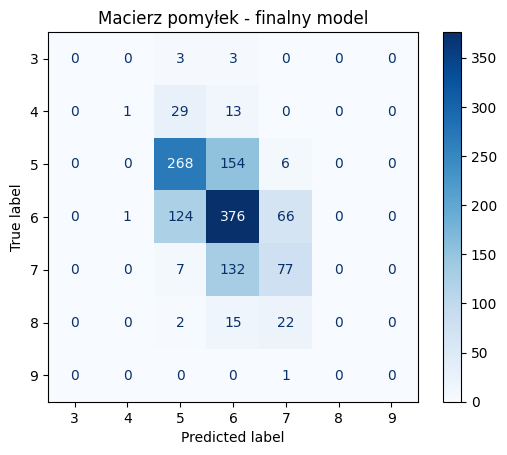

In [18]:
# Macierz pomyłek dla finalnego modelu
cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=best_model.classes_).plot(cmap='Blues')
plt.title('Macierz pomyłek - finalny model')
plt.show()

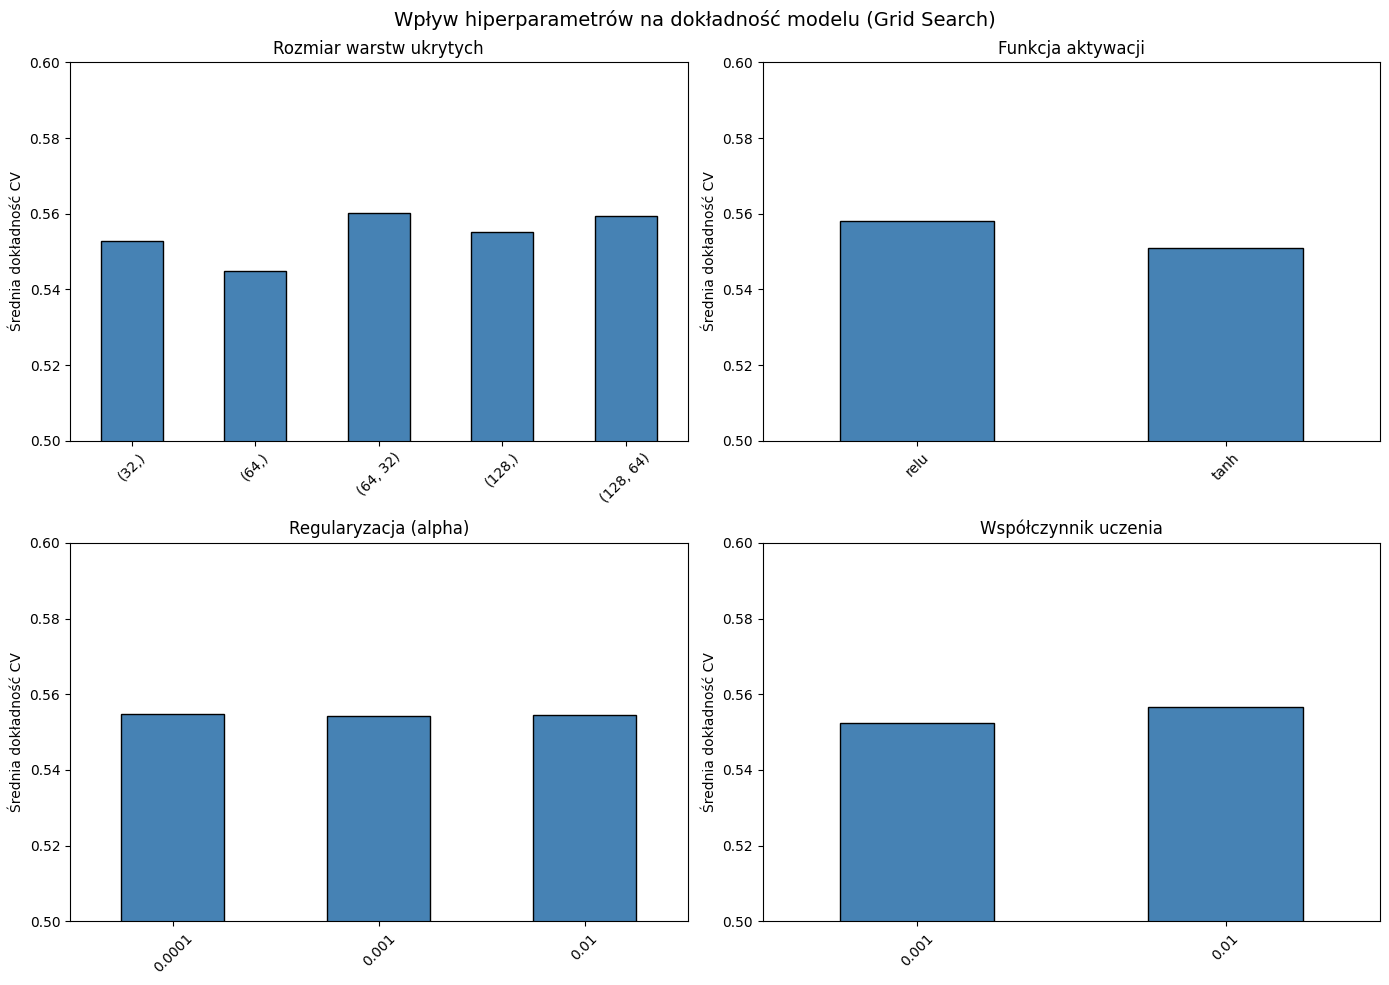

In [19]:
# Wizualizacja wpływu hiperparametrów na dokładność modelu w Grid Search
results = pd.DataFrame(grid.cv_results_)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wpływ hiperparametrów na dokładność modelu (Grid Search)', fontsize=14)

params_to_plot = [
    ('param_hidden_layer_sizes', 'Rozmiar warstw ukrytych', axes[0, 0]),
    ('param_activation',         'Funkcja aktywacji',       axes[0, 1]),
    ('param_alpha',              'Regularyzacja (alpha)',   axes[1, 0]),
    ('param_learning_rate_init', 'Współczynnik uczenia',    axes[1, 1]),
]

for param, label, ax in params_to_plot:
    results.groupby(param)['mean_test_score'].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('Średnia dokładność CV')
    ax.set_ylim(0.50, 0.60)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

  Model  Accuracy
 Bazowy  0.554615
Finalny  0.555385


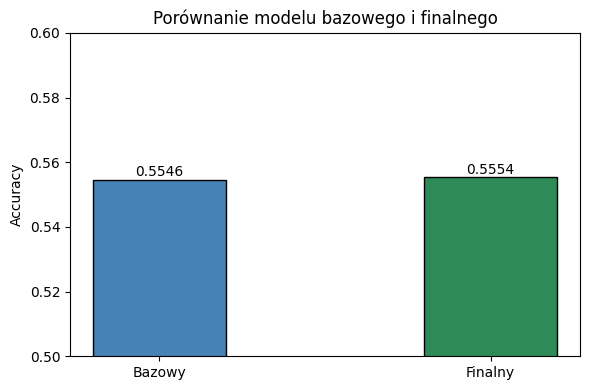

In [20]:
# Porównanie modelu bazowego i finalnego
porownanie = pd.DataFrame({
    'Model': ['Bazowy', 'Finalny'],
    'Accuracy': [clf.score(X_test_scaled, y_test), best_model.score(X_test_scaled, y_test)],
})

print(porownanie.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(porownanie['Model'], porownanie['Accuracy'], color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
ax.set_ylim(0.50, 0.60)
ax.set_ylabel('Accuracy')
ax.set_title('Porównanie modelu bazowego i finalnego')
for i, v in enumerate(porownanie['Accuracy']):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()